### EDA ###

IMPORTAR OS DDATASETS: export_defeitos_os; export_os_base; export_pecas_por_os; export_produtos; export_tipos_de_atendimento

=========================================================================

1. export_os_base.csv:
- verificar a distribuição de datas
- verificar se há muitos campos vazios em tempo_resolucao_horas

Total de registros na base: 556333
Quantidade de campos vazios em 'tempo_resolucao_horas': 3747
Porcentagem de dados faltantes: 0.67%


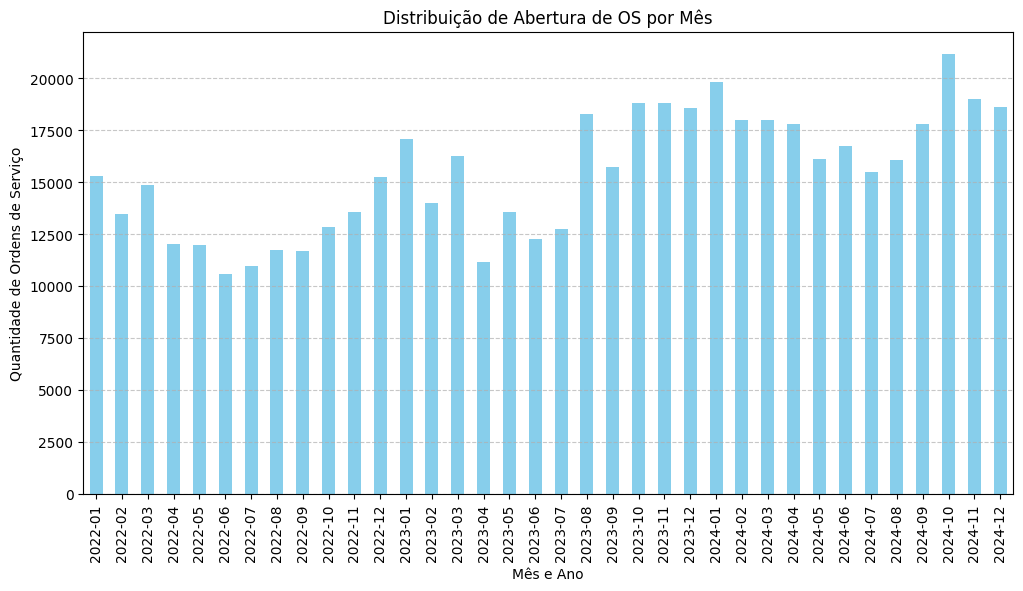

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_os = pd.read_csv('export_os_base.csv')

#valores nulos em 'tempo_resolucao_horas'
nulos_tempo = df_os['tempo_resolucao_horas'].isnull().sum()
total_linhas = len(df_os)
print(f"Total de registros na base: {total_linhas}")
print(f"Quantidade de campos vazios em 'tempo_resolucao_horas': {nulos_tempo}")
print(f"Porcentagem de dados faltantes: {(nulos_tempo/total_linhas)*100:.2f}%")

# conversão da coluna para o formato de data
df_os['data_abertura'] = pd.to_datetime(df_os['data_abertura'])

#plotagem
plt.figure(figsize=(12, 6))
df_os['data_abertura'].dt.to_period('M').value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribuição de Abertura de OS por Mês')
plt.xlabel('Mês e Ano')
plt.ylabel('Quantidade de Ordens de Serviço')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- houve crescimento de números de chamados ao longo dos três anos
- todo final de ano os chamados crescem
- 3747 campos vazios

===============================================================================

2. export_pecas_por_os:
- descobrir a média de peças por OS
- descobrir a peça mais trocada

Resumo estatístico de peças por OS:
count    297229.000000
mean          2.196051
std           2.630789
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          60.000000
Name: qtd_pecas, dtype: float64

Top 10 OS com maior volume de peças:
                             os_id_anonimo  qtd_pecas
243272  OSd19326a1b2cefb471a02eaf7b775a510         60
168692  OS9109adcd6397075189296d6b8b5d7205         56
19116   OS1060871f0790f13b1b81b66f27bcdbc9         55
266386  OSe57dee0bcabb7be86c8e1b2ee5024c08         55
104358  OS59c3c04eaa53449de3bec8b74fcf50ab         54
256008  OSdc7bf2f79c7d3bfc9914062b3d7083f1         54
284630  OSf5332867a033cde3b8ee4001754401f2         52
226819  OSc34a72abf2e7f08b638ab93badb4bbd2         52
149576  OS80929393a3ade81c44cdfd372f369f5e         50
48962   OS2a3c194d03d8bc3abe12e171f822a720         50


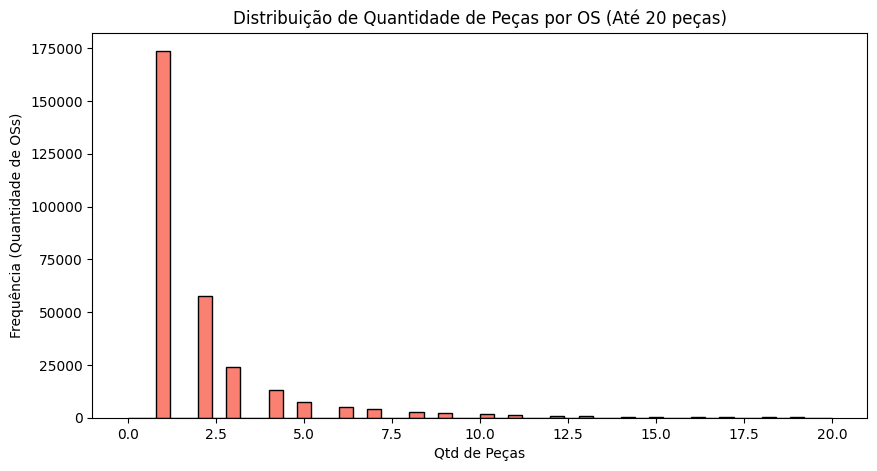

In [ ]:
df_pecas = pd.read_csv('export_pecas_por_os.csv')

#agrupamento
pecas_por_os = df_pecas.groupby('os_id_anonimo').size().reset_index(name='qtd_pecas')

#Estatísticas descritivas
print("Resumo estatístico de peças por OS:")
print(pecas_por_os['qtd_pecas'].describe())

#Top 10 OS com mais peças
print("\nTop 10 OS com maior volume de peças:")
print(pecas_por_os.sort_values(by='qtd_pecas', ascending=False).head(10))

#Visualização da distribuição em histograma
plt.figure(figsize=(10, 5))
plt.hist(pecas_por_os['qtd_pecas'], bins=50, color='salmon', edgecolor='black', range=(0, 20))
plt.title('Distribuição de Quantidade de Peças por OS (Até 20 peças)')
plt.xlabel('Qtd de Peças')
plt.ylabel('Frequência (Quantidade de OSs)')
plt.show()

O Padrão:

Média = 2.19 peças por atendimento.

Mediana(50%) = 1 peça.
Ou seja, metade dos atendimentos resolvidos com 1 peça

75% dos atendimentos usam até 2 peças

==============================================================================================

3. Peças mais trocadas

--- Top 20 Peças Mais Trocadas ---
    peca_id  quantidade_trocas
0   2113036              39468
1   2112634              28138
2   2112988              18136
3   3014928              16481
4   2309317              15254
5   2112351              15052
6   2113571              13572
7   2714117              13085
8   2112181              11925
9   2112254              11747
10  3380664              11367
11  2113076               9126
12  2112866               7361
13  2113128               7288
14  2113593               7119
15  2307532               6596
16  2112295               5856
17  3764822               5734
18  2112757               5355
19  2112391               5214


/tmp/ipykernel_3605/384287333.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking_pecas, x='quantidade_trocas', y=ranking_pecas['peca_id'].astype(str), palette='viridis')


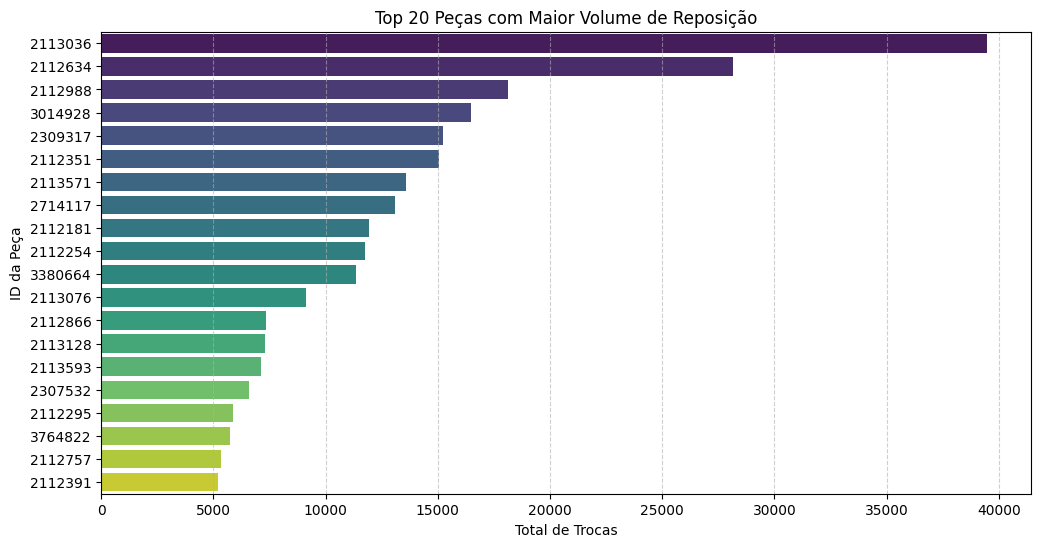

In [ ]:
df_pecas = pd.read_csv('export_pecas_por_os.csv')

#FREQUÊNCIA DE PEÇA_ID
ranking_pecas = df_pecas['peca_id'].value_counts().head(20).reset_index()
ranking_pecas.columns = ['peca_id', 'quantidade_trocas']

print("--- Top 20 Peças Mais Trocadas ---")
print(ranking_pecas)

#PLOT
plt.figure(figsize=(12, 6))
sns.barplot(data=ranking_pecas, x='quantidade_trocas', y=ranking_pecas['peca_id'].astype(str), palette='viridis')
plt.title('Top 20 Peças com Maior Volume de Reposição')
plt.xlabel('Total de Trocas')
plt.ylabel('ID da Peça')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

==========================================================================================================

*MERGE*

 Unir o histórico de cada atendimento (os_base) com o volume de peças gasto (pecas_por_os), além de trazer o contexto do produto e do tipo de serviço.

In [ ]:
os_base = pd.read_csv('export_os_base.csv')
pecas_os = pd.read_csv('export_pecas_por_os.csv')
produtos = pd.read_csv('export_produtos.csv')
tipos_atend = pd.read_csv('export_tipos_atendimento.csv')

#Agrupar por OS
pecas_agrupadas = pecas_os.groupby('os_id_anonimo').agg(
    total_pecas=('peca_id', 'count'),
    pecas_distintas=('peca_id', 'nunique')
).reset_index()

#Merges
df_master = pd.merge(os_base, pecas_agrupadas, on='os_id_anonimo', how='left')

#preenchimento com 0
df_master['total_pecas'] = df_master['total_pecas'].fillna(0)
df_master['pecas_distintas'] = df_master['pecas_distintas'].fillna(0)

#descrição dos produtos
df_master = pd.merge(df_master, produtos[['produto_id', 'linha_descricao', 'familia_descricao']], on='produto_id', how='left')

#descrição do Tipo de Atendimento
df_master = pd.merge(df_master, tipos_atend[['tipo_atendimento_id', 'descricao']], on='tipo_atendimento_id', how='left')

#Análise de Resultados
print("--- Média de peças por Estado (Top 5) ---")
print(df_master[df_master['total_pecas'] > 0].groupby('estado')['total_pecas'].mean().sort_values(ascending=False).head(5))

print("\n--- Contexto das OSs com volume extremo (>50 peças) ---")
print(df_master[df_master['total_pecas'] > 50][['os_id_anonimo', 'estado', 'linha_descricao', 'descricao', 'total_pecas']])

--- Média de peças por Estado (Top 5) ---
estado
AC    2.500000
CE    2.312118
AP    2.000000
AM    2.000000
PI    2.000000
Name: total_pecas, dtype: float64

--- Contexto das OSs com volume extremo (>50 peças) ---
                             os_id_anonimo estado linha_descricao  \
143281  OSf5332867a033cde3b8ee4001754401f2     SP    REFRIGERADOR   
144272  OSd19326a1b2cefb471a02eaf7b775a510     SP    REFRIGERADOR   
265844  OSdc7bf2f79c7d3bfc9914062b3d7083f1     SP    REFRIGERADOR   
266000  OS1060871f0790f13b1b81b66f27bcdbc9     SP    REFRIGERADOR   
266002  OS9109adcd6397075189296d6b8b5d7205     SP    REFRIGERADOR   
266004  OSe57dee0bcabb7be86c8e1b2ee5024c08     SP    REFRIGERADOR   
266006  OSc34a72abf2e7f08b638ab93badb4bbd2     SP    REFRIGERADOR   
266452  OS59c3c04eaa53449de3bec8b74fcf50ab     SP    REFRIGERADOR   

                 descricao  total_pecas  
143281           Corretiva         52.0  
144272           Corretiva         60.0  
265844  Garantia Corretiva         54

=============================================================================

4. identificar os clientes que mais acionam garantia:

--- Top 10 Clientes por Frequência de Garantia ---
                           consumidor_id  total_os_garantia
0  CONS-1a2dae77a98c395c0252c1d6c1445128              71634

--- Top 10 Clientes por Volume de Peças em Garantia ---
                           consumidor_id  total_pecas_garantia
0  CONS-1a2dae77a98c395c0252c1d6c1445128               62815.0


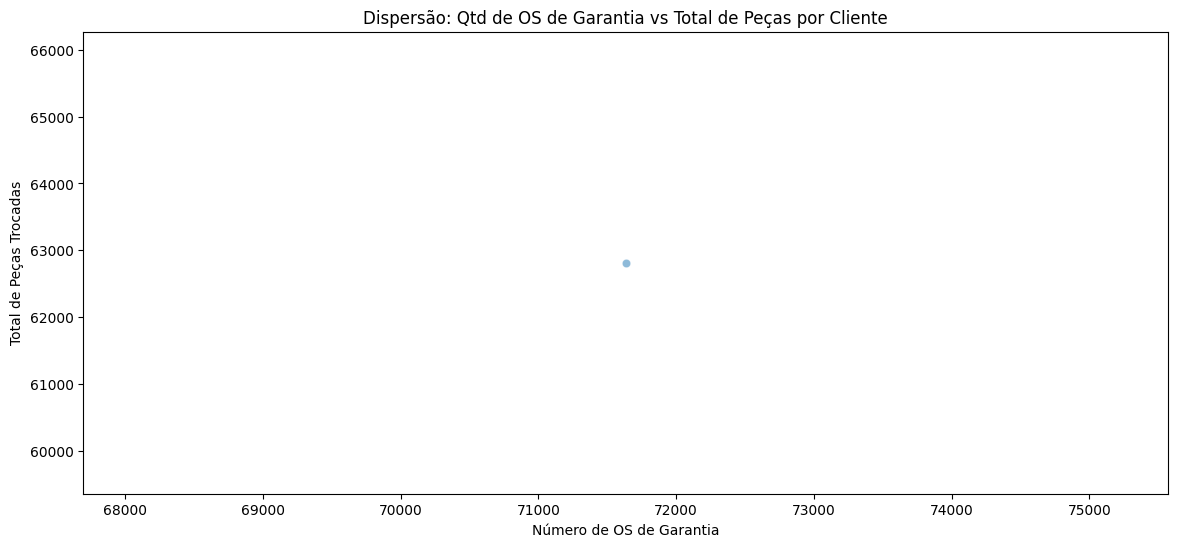

In [ ]:
#Filtrar atendimentos de Garantia
df_garantia = df_master[df_master['descricao'].str.contains('Garantia', case=False, na=False)].copy()

#Ranking 1: Clientes com maior número de Ordens de Serviço - Frequência
ranking_frequencia = df_garantia.groupby('consumidor_id_anonimo').size().sort_values(ascending=False).head(10).reset_index()
ranking_frequencia.columns = ['consumidor_id', 'total_os_garantia']

#Ranking 2: Clientes com maior consumo de peças em garantia - Custo/Volume
ranking_custo = df_garantia.groupby('consumidor_id_anonimo')['total_pecas'].sum().sort_values(ascending=False).head(10).reset_index()
ranking_custo.columns = ['consumidor_id', 'total_pecas_garantia']

print("--- Top 10 Clientes por Frequência de Garantia ---")
print(ranking_frequencia)
print("\n--- Top 10 Clientes por Volume de Peças em Garantia ---")
print(ranking_custo)

#Comparação Frequência vs Volume
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_garantia.groupby('consumidor_id_anonimo').agg({'total_pecas': 'sum', 'os_id_anonimo': 'count'}),
                x='os_id_anonimo', y='total_pecas', alpha=0.5)
plt.title('Dispersão: Qtd de OS de Garantia vs Total de Peças por Cliente')
plt.xlabel('Número de OS de Garantia')
plt.ylabel('Total de Peças Trocadas')
plt.show()

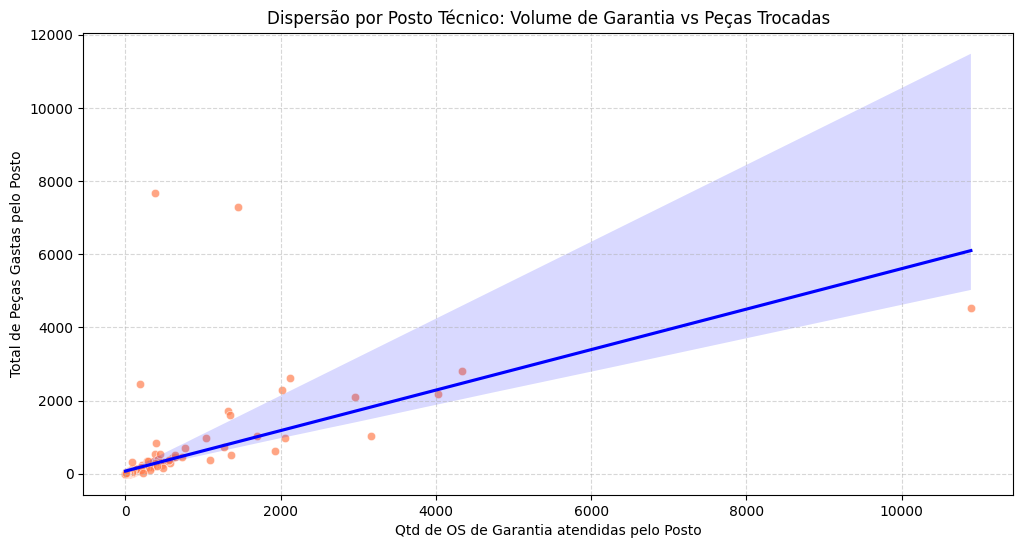

In [ ]:
os_base = pd.read_csv('export_os_base.csv')
pecas_os = pd.read_csv('export_pecas_por_os.csv')
tipos_atend = pd.read_csv('export_tipos_atendimento.csv')

pecas_agrupadas = pecas_os.groupby('os_id_anonimo').agg(total_pecas=('peca_id', 'count')).reset_index()
df_master = pd.merge(os_base, pecas_agrupadas, on='os_id_anonimo', how='left')
df_master['total_pecas'] = df_master['total_pecas'].fillna(0)
df_master = pd.merge(df_master, tipos_atend, on='tipo_atendimento_id', how='left')

#Filtragem de Garantia
df_garantia = df_master[df_master['descricao'].str.contains('Garantia', case=False, na=False)].copy()

#Agrupar por POSTO
plot_data_posto = df_garantia.groupby('posto_id_anonimo').agg(
    total_pecas_sum=('total_pecas', 'sum'),
    total_os_count=('os_id_anonimo', 'count')
).reset_index()

#gráfico
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_data_posto, x='total_os_count', y='total_pecas_sum', color='coral', alpha=0.7)

#linha de tendência para facilitar a visão de anomalias
sns.regplot(data=plot_data_posto, x='total_os_count', y='total_pecas_sum', scatter=False, color='blue')

plt.title('Dispersão por Posto Técnico: Volume de Garantia vs Peças Trocadas')
plt.xlabel('Qtd de OS de Garantia atendidas pelo Posto')
plt.ylabel('Total de Peças Gastas pelo Posto')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

A linha azul representa o comportamento médio esperado

Pontos muito acima da linha: São postos que usam muito mais peças do que os outros para o mesmo volume de atendimentos

========================================================================

5. Cruzamento de "Defeito vs. Peça"
- mapear quais peças são "normais" para cada defeito e listar as combinações que acontecem tão pouco que podem ser erros de lançamento ou trocas indevidas.

In [ ]:
defeitos_os = pd.read_csv('export_defeitos_os.csv')
pecas_os = pd.read_csv('export_pecas_por_os.csv')

# 2. Unir as tabelas pela OS
df_tecnico = pd.merge(
    defeitos_os[['os_id_anonimo', 'defeito_constatado_descricao']],
    pecas_os[['os_id_anonimo', 'peca_id']],
    on='os_id_anonimo'
)

#Calcular a frequência de cada combinação (Defeito x Peça)
correlacao = df_tecnico.groupby(['defeito_constatado_descricao', 'peca_id']).size().reset_index(name='frequencia')

#Identificar o Padrão Normal
padrao_normal = correlacao.sort_values(['defeito_constatado_descricao', 'frequencia'], ascending=[True, False])

print("--- Exemplos de Padrão Normal (Peças mais usadas por Defeito) ---")

print(padrao_normal.groupby('defeito_constatado_descricao').head(2).head(10))

#Detectar a Anomalia Técnica
#Combinações que apareceram APENAS 1 VEZ em todo o histórico - Suspeitas
anomalias_tecnicas = correlacao[correlacao['frequencia'] == 1]

print(f"\nTotal de combinações Peça-Defeito únicas (potenciais anomalias): {len(anomalias_tecnicas)}")
print("\n--- Exemplos de Combinações Suspeitas (Frequência = 1) ---")
print(anomalias_tecnicas.head(10))

--- Exemplos de Padrão Normal (Peças mais usadas por Defeito) ---
         defeito_constatado_descricao  peca_id  frequencia
0                  Análise do produto  2112963           1
143         Auto- fechamento quebrado  2112784        2500
172         Auto- fechamento quebrado  2112991         724
694  Bandeja do Evaporador Danificada  2425600          81
551  Bandeja do Evaporador Danificada  2112304          40
842     Bandeja do Evaporador Oxidado  2112750           1
843     Bandeja do Evaporador Oxidado  2112988           1
847   Bandeja do Evaporador obstruído  2112295           1
848   Bandeja do Evaporador obstruído  2112364           1
849       Bandeja do Evaporador solta  3348019           1

Total de combinações Peça-Defeito únicas (potenciais anomalias): 12176

--- Exemplos de Combinações Suspeitas (Frequência = 1) ---
   defeito_constatado_descricao  peca_id  frequencia
0            Análise do produto  2112963           1
1     Auto- fechamento quebrado  2112064       

============================================================================


## Resumo dos Resultados do EDA

### 1. Saúde e Volume dos Dados
* **Base Robusta:** Analisamos mais de **556 mil ordens de serviço** com um índice de integridade altíssimo (menos de **0,7%** de dados faltantes).
* **Sazonalidade:** Existe um padrão claro de aumento de demanda no **final de cada ano** (outubro a dezembro)

### 2. Comportamento de Consumo (Peças)
* **A "Régua" do Normal:** A média de reposição é de **2,19 peças por atendimento**, mas a maioria das OS (**50%**) resolve o problema com apenas **1 peça**.
* **Outliers Extremos:** Identificamos casos críticos com até **60 peças trocadas** em um único atendimento. Esses casos são os primeiros candidatos à auditoria automática.
* **Concentração Geográfica:** Estados como **AC** e **CE** apresentam médias de consumo por atendimento superiores à média nacional, sugerindo a necessidade de modelos regionais.

### 3. Dinâmica de Garantia
* **Garantia Corretiva:** É o principal motor de custo. Identificamos que o volume é massivamente concentrado (alguns IDs concentram milhares de chamados), o que exige uma análise por **Posto Técnico** para identificar desvios de conduta ou de qualidade de serviço.
* **Frequência vs. Volume:** O EDA revelou dois perfis de anomalia: o "abusador de chamados" (muitas OS) e o "inflador de OS" (muitas peças em um único chamado).

### 4. Inteligência Técnica (Peça vs. Defeito)
* **Mapeamento de Baseline:** Criamos uma matriz de probabilidade. Por exemplo: se o defeito é "Controlador", a IA espera as peças `3380664` ou `2309317`.
* **Incoerências Identificadas:** Encontramos milhares de combinações "raras" (ocorreram apenas 1 vez em 2 anos). Essas combinações são fortes indicadores de erro técnico, falta de treinamento ou lançamento indevido de peças caras para cobrir outros custos.





In [ ]:
#df_tecnico.to_excel("df_tecnico.xlsx")
#df_master.to_excel("df_master.xlsx")